# Inżynieria lingwistyczna
Ten notebook jest oceniany półautomatycznie. Nie twórz ani nie usuwaj komórek - struktura notebooka musi zostać zachowana. Odpowiedź wypełnij tam gdzie jest na to wskazane miejsce - odpowiedzi w innych miejscach nie będą sprawdzane (nie są widoczne dla sprawdzającego w systemie).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".

---

# Zadanie 1 - tokenizacja (12 pkt)

Jedną z nowoczesnych technik tokenizacji jest BPE - byte-pair encoding [1]. Technika ta polega na podzielenie słów na częste podsłowa (a'la morfemy?). W przeciwieństwie do podejść lingwistycznych, wymagających zwykle ręcznie napisanych reguł tworzenia morfemów czy nawet słowników lematów, BPE znajduje je heurystycznie poprzez wyznaczenie najczęstszych przylegających do siebie sekwencji znaków.

Algorytm przebiega w następujących krokach.
1. Podziel wszystkie słowa na symbole (początkowo pojedyncze znaki)
2. Wyznacz najczęściej występującą obok siebie parę symboli 
3. Stwórz nowy symbol będący konkatenacją dwóch najczęstszych symboli.

Uwaga 1: każde słowo zakończone jest specjalnym symbolem końca wyrazu.

Uwaga 2: tworzenie nowego symbolu nie powoduje usuniecie starego tj. zawsze jednym z możliwych symboli jest pojedynczy znak, ale jeśli można to stosujemy symbol dłuższy.

Przykład: korpus w którym występuje ,,ala'' 5 razy i ,,mama 10 razy''
1. Dzielimy słowa na symbole ,,a l a END'' ,,m a m a END''  gdzie END jest symbolem końca wyrazu.
2. Najczęstsza para obok siebie to ,,m a'' (20 razy)
3. Nowy symbol ,,ma''
4. Nowy podział ,,a l a END'' ,,ma ma END''
5. Najczęstsza para ,,ma ma'' (10 razy)
6. Nowy symbol ,,mama''
7. Nowy podział ,,a l a END'' ,,mama END''
8. itd.

W pliku ,,brown_clusters.tsv'' pierwsza kolumna to identyfikator skupienia (nie używamy w tym zadaniu), druga kolumna to wyrazy, a trzecia to ich liczności w pewnym korpusie tweetów. Zaimplementuj technikę BPE i przetesuj ją na tych słowach.

Parametrem algorytmu BPE jest `number_of_iterations` czyli liczba iteracji (łączeń symboli). Dodatkowo implementacja powinna mieć parametr `verbose`, którego wartość `True` powinna skutkować wypisywaniem na konsolę wykonywanych operacji (tj. łączeń).

[1] Sennrich, R., Haddow, B., and Birch, A. (2016). Neural machine translation of rare words with subword units. In ACL 2016.

In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict
brown_df = pd.read_csv('brown_clusters.tsv', sep='\t', header=0, names=['cluster', 'word', 'count'])

number_of_iterations = 10
def preform_bpe(brown_df, number_of_iterations, verbose = False):
    """
    Funkcja przyjmuje ramkę w formacie analogicznym do obiektu brown_df (wczytany wyżej)
     oraz liczbę iteracji.
    Wyjściem funkcji powinna być lista słów z poszczególnymi tokenami/symbolami oddzielonymi spacją.
    Za znak końca wyrazu przyjmij END. 
    """
    # WPISZ TWÓJ KOD TUTAJ
    corpus = []
    for word, count in zip(brown_df['word'], brown_df['count']):
        # Convert word to string to handle 'null', 'nan', 'n/a', empty strings
        word = str(word)
        corpus.append((list(word) + ["END"], count))
    
    # Count all adjacent symbol pairs across the corpus
    def count_pairs(corpus):
        pair_freq = defaultdict(int)
        for symbols, freq in corpus:
            for i in range(len(symbols) - 1):
                pair = (symbols[i], symbols[i+1])
                pair_freq[pair] += freq
        return pair_freq
    
    # Merge the most frequent pair
    def merge_pair(corpus, target_pair, new_symbol):
        new_corpus = []
        for symbols, freq in corpus:
            merged = []
            skip_next = False
            for i in range(len(symbols)):
                if skip_next:
                    skip_next = False
                    continue
                if i < len(symbols) - 1 and (symbols[i], symbols[i+1]) == target_pair:
                    merged.append(new_symbol)
                    skip_next = True
                else:
                    merged.append(symbols[i])
            new_corpus.append((merged, freq))
        return new_corpus
    
    for step in range(number_of_iterations):
        pairs = count_pairs(corpus)
        if not pairs:
            break
        most_frequent_pair = max(pairs.items(), key=lambda x: x[1])[0]
        new_symbol = ''.join(most_frequent_pair)
        # if verbose:
        #     print(f"Step {step+1}: merging pair {most_frequent_pair} -> '{new_symbol}' (frequency: {pairs[most_frequent_pair]})")
        corpus = merge_pair(corpus, most_frequent_pair, new_symbol)
    
    result = [' '.join(symbols) for symbols, _ in corpus]
    
    return result

Test implementacji:

In [2]:
from unittest import TestCase

tc = TestCase()
data = {'cluster': range(2), 'word': ['ala', 'mama'], 'count': [5, 10]}
df = pd.DataFrame(data, columns=['cluster', 'word', 'count'])
vocab = preform_bpe(df, 1)
tc.assertListEqual(vocab, ['a l a END', 'ma ma END'])

Spraw aby Twoja implementacja wypisywała kolejne łączone ze sobą symbole (parametr `verbose`) i uruchom Twoją funkcję na np. 50 iteracji, obserwując jakie tokeny są tworzone.

In [3]:
preform_bpe(brown_df, 50, verbose=True)

['\\ iEND',
 '/ i / END',
 't o d a y - iEND',
 'n ow iEND',
 '# you e v erEND',
 'i f in al l yEND',
 '「 iEND',
 '- i - END',
 'in e v aEND',
 '» iEND',
 'w ha t t a y aEND',
 'i i i i i i i i i iEND',
 '\ue6d1 END',
 'i k in d aEND',
 'l o l - iEND',
 'i a c t u al l yEND',
 'w a d d y aEND',
 '# a s l on g a s you END',
 'd o you END',
 '\u200e \u200b iEND',
 'i ̇ END',
 'ï END',
 '# l o l a t g i r l s w h oEND',
 '# r t i f you END',
 'i j s tEND',
 '« iEND',
 '• iEND',
 'w h o d aEND',
 'w ha d y aEND',
 ') iEND',
 '+ iEND',
 '# you r f a c e m a k e s m eEND',
 'i i i i i i i iEND',
 '` iEND',
 'i i i i i i iEND',
 'i al re a d yEND',
 '_ iEND',
 '# you m a k e m eEND',
 '* iEND',
 '| iEND',
 '# u r b o y f r i en d e v erEND',
 'w h en iEND',
 'ι END',
 "d on ' t c h aEND",
 "w h o ' d aEND",
 'd you END',
 'w ha d d a y aEND',
 'i on l yEND',
 'i j u s sEND',
 'i al w a y sEND',
 'i i i i iEND',
 'd on c h aEND',
 '( iEND',
 "d ' y aEND",
 'ı END',
 '# u e v erEND',
 'in e v e

- Jakie angielskie słowo jako pierwsze dostało swój własny token?

```Step 4: merging pair ('i', 'n') -> 'in' (frequency: 54421642)```

Słowo "in"

- Jakie są zalety korzystania z tokenizacji BPE w kontekście tworzenia reprezentacji do problemu klasyfikacji tekstu (problem OOV, odnieś się do k-gramów i n-gramów)? Jakie są zalety BPE w przypadku przetwarzania różny rodzajów języków (np. fleksyjne, aglutynacyjne)?

BPE skutecznie rozwiązuje problem słów spoza słownika (OOV). Tokenizacja oparta na słowach lub n-gramach, każde nowe lub rzadko spotykane słowo może być całkowicie nieznane modelowi, co prowadzi do utraty informacji i pogorszenia jakości reprezentacji. BPE zamiast tego dzieli słowa na mniejsze jednostki, które mogą być łączone w celu odtworzenia nowych wyrazów. Dzięki temu nawet nieznane słowo może zostać zrozumiane na podstawie znanych fragmentów.

W porównaniu z klasycznymi k-gramami lub n-gramami, BPE oferuje bardziej zwięzły i adaptacyjny słownik. O ile k-gramy generują wszystkie możliwe ciągi znaków o długości k, przez co liczba potencjalnych tokenów rośnie wykładniczo, BPE iteracyjnie łączy tylko te pary symboli, które najczęściej współwystępują. W efekcie powstaje słownik o optymalnym rozmiarze, dopasowany do statystyki konkretnego korpusu językowego.

W językach fleksyjnych (np. polski, niemiecki) oraz aglutynacyjnych (np. węgierski, turecki), gdzie słowa mogą przybierać bardzo wiele form poprzez dodawanie przedrostków, przyrostków i afiksów, klasyczna tokenizacja słownikowa prowadzi do ogromnej liczby unikalnych słów. BPE ogranicza tę eksplozję słownika, ponieważ pozwala rozkładać wyrazy na wspólne morfemy lub cząstki znaczeniowe. W efekcie model może skuteczniej generalizować i rozpoznawać podobne konstrukcje morfologiczne.

Wróć do implementacji i zakomentuj wypisywanie (funkcje print) informacji z funkcji `preform_bpe`.

# Zadanie 2 - klasyfikacja (15 pkt)

Poniższy kod powinien wczytać i ztokenizować zbiór danych dot. analizy wydźwięku. Jeśli nie masz biblioteki `nltk` musisz ją zainstalować.

In [4]:
from helpers import DataSet
training_set = DataSet(['tweets.txt'])

Reading data set ['tweets.txt']


Poniżej znajdziesz przykład odczytu jednego tweeta z obiektu DataSet

In [5]:
for i in training_set.tweets:
    print(i.text)
    print(i.tokens)
    print(i.clazz)
    break

dear @Microsoft the newOoffice for Mac is great and all, but no Lync update? C'mon.
['dear', '@microsoft', 'the', 'newooffice', 'for', 'mac', 'is', 'great', 'and', 'all', ',', 'but', 'no', 'lync', 'update', '?', "c'mon", '.']
negative


Systemy IL często pracują z bardzo dużą liczbą cech, które są rzadkie np. cechy Bag-Of-Words, cechy n-gramowe itd. Powoduje to że klasyczna macierz zawierająca przykłady uczące ($n$) i cechy ($d$) rośnie do bardzo dużych rozmiarów ($nd$) nawet dla małych zbiorów uczących (w sensie liczby przykładów). Ponadto samo przechowywanie w pamięci słownika mapującego konkretne słowa/n-gramy na indeksy kolumn macierzy może być bardzo kosztowne pamięciowo przy dużych rozmiarach słownika.

Istnieje jednak technika, która pozwala nam na ominięcie tej przeszkody: haszowanie cech. Opis tej techniki znajdziesz na stronie:  https://en.wikipedia.org/wiki/Feature_hashing Jest ona też implementowana w obiekcie `sklearn.feature_extraction.FeatureHasher`. Zapoznaj się z opisem techniki i wykonaj poniższe polecenia.

- Wykorzystując haszowanie cech wytrenuj wybrany klasyfikator (najlepiej taki, który się szybko liczy) na zbiorze uczącym dla cech Bag-of-words (możesz też spróbować cechy n-gramowe). Możesz wykorzystać gotową tokenizację we właściwości `.tokens`.

In [6]:
import pandas as pd
from sklearn.feature_extraction import FeatureHasher
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from nltk import ngrams
from helpers import DataSet

training_set = DataSet(['tweets.txt'])

def add_ngrams(tokens, n=2):
    bigrams = ['_'.join(ng) for ng in ngrams(tokens, n)]
    return tokens + bigrams

X = [add_ngrams(tweet.tokens) for tweet in training_set.tweets]
y = [tweet.clazz for tweet in training_set.tweets]

split = 0.2
seed = 13
n_features = 2048
Clas = LogisticRegression

def make_dataset(n_features):
    h = FeatureHasher(n_features=n_features, input_type='string')
    X_hashed = h.transform(X)
    return train_test_split(X_hashed, y, test_size=split, random_state=seed)

X_tr, X_te, y_tr, y_te = make_dataset(n_features=n_features)
model = Clas(max_iter=1000)
model.fit(X_tr, y_tr)
score = model.score(X_te, y_te)

print(f"Model accuracy with bigrams (n_features={n_features}): {score:.3f}")

Reading data set ['tweets.txt']
Model accuracy with bigrams (n_features=2048): 0.536


- Stwórz wykres zależności wybranej miary klasyfikacji od wymiarów macierzy danych (chodzi o liczbę cech do których haszujemy cechy oryginalne). Wystarczy przetestować kilka (>=4) wybranych wartości na skali logarytmicznej.

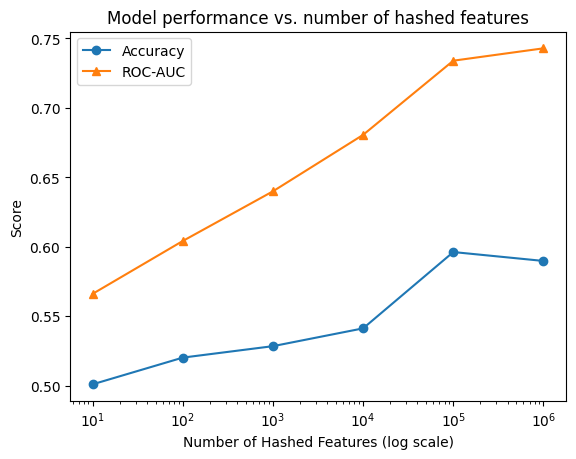

In [7]:
import matplotlib.pyplot as plt
from sklearn import metrics

ns = [10**i for i in range(1, 7)]
acc, auc = [], []

for n in ns:
    X_tr, X_te, y_tr, y_te = make_dataset(n_features=n)
    model = Clas(max_iter=1000)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    acc.append(metrics.accuracy_score(y_te, y_pred))
    y_prob = model.predict_proba(X_te)
    auc.append(metrics.roc_auc_score(y_te, y_prob, multi_class='ovr'))

plt.plot(ns, acc, label='Accuracy', marker='o')
plt.plot(ns, auc, label='ROC-AUC', marker='^')
plt.xscale('log')
plt.xlabel('Number of Hashed Features (log scale)')
plt.ylabel('Score')
plt.legend()
plt.title('Model performance vs. number of hashed features')
plt.show()


 - Obserwując stworzony wykres - skomentuj. Jak dużo jakości klasyfikacji się traci (albo zyskuje?) korzystając z mniejszej liczby haszowanych cech? Często klasyfikatory bardzo dobrze działają nawet przy liczbie haszowanych cech dla których na pewno istnieją konflikty cech oryginalnych - jak myślisz dlaczego? (Pomyśl o interpretacji takich skonfliktowanych cech).

Dla regresji logistycznej jakość klasyfikacji rośnie z ok. 0.50 do 0.60 przy zwiększaniu liczby cech z 10 do 100 000, a ROC-AUC z ~0.56 do ~0.74. Powyżej tej liczby przyrosty są minimalne, więc utrata jakości przy mniejszej liczbie cech to ok. 8–10%.

Klasyfikator mimo kolizji działa dobrze, ponieważ kolidujące cechy mogą nieść podobną informację, a losowe znaki w haszowaniu powodują, że błędy częściowo się znoszą. W efekcie haszowanie działa jak regularizacja, ograniczając nadmiar cech bez dużej utraty jakości.

 - W poprzednim zadaniu wczytałeś wynik grupowania Browna do pamięci. Wytrenuj klasyfikator na reprezentacji ,,Bag-of-clusters'' tj. w kolumnach zamiast słów/n-gramów będziesz miał grupy.

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split

clusters = brown_df.cluster.unique()
cluster_vectors = dict(zip(clusters, np.eye(len(clusters))))

word_to_cluster = {w: cluster_vectors[c] for w, c in zip(brown_df.word, brown_df.cluster)}

X = np.array([
    np.sum([word_to_cluster[t] for t in tweet.tokens if t in word_to_cluster], axis=0)
    for tweet in training_set.tweets
])

y = [tweet.clazz for tweet in training_set.tweets]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=split, random_state=seed)
score = Clas().fit(X_tr, y_tr).score(X_te, y_te)
print("Score:", score)
print("Shape of X:", X.shape)


Score: 0.5631868131868132
Shape of X: (5459, 937)


- Podsumuj eksperymenty: poznałeś dwie możliwości ograniczenia liczby cech - zastąpienie słów ich grupami i haszowanie cech. Jakie są wady i zalety obydwu podejść?

Regresja logistyczna z hashowanymi cechami bigramów (n_features=2048) osiągnęła **accuracy 0.536**. Reprezentacja Bag-of-Clusters (n_features=937) osiągnęła **accuracy 0.563**, przy wymiarze macierzy `(5459, 937)`. Widać, że mimo mniejszej liczby cech Bag-of-Clusters daje porównywalną jakość klasyfikacji.  

**Hashowanie cech:**  
- **Zalety:** proste, szybkie obliczeniowo, nie wymaga wcześniejszego korpusu (brak problemu OOV).  
- **Wady:** możliwe kolizje cech, funkcja hashująca nie wykorzystuje żadnej informacji semantycznej.  

**Bag-of-Clusters:**  
- **Zalety:** pozwala grupować słowa semantycznie (np. poprzez kontekst w klastrach Browna), co poprawia uogólnienie modelu.  
- **Wady:** wymaga wstępnego grupowania słów w korpusie, słowa spoza korpusu są OOV i nie mają reprezentacji.  

Bag-of-Clusters daje możliwość semantycznej generalizacji, a hashowanie jest bardziej elastyczne i łatwe do skalowania.
